In [1]:
import os
import cv2
import time
import pytz
import sqlite3
import numpy as np
import pandas as pd
from tkinter import *
import face_recognition
from datetime import datetime
from tkinter import messagebox
from PIL import ImageTk,Image
import matplotlib.pyplot as plt

In [34]:
conn=sqlite3.connect('Attendance1.db')
cursor=conn.cursor()
cursor.execute('''create table present_list2(USNS text,
NAMES text,
DATE text,
TIME text)''')
conn.commit()
conn.close()

In [41]:
def image_capturing():
    reg_name=reg_name_entry.get()
    reg_name=reg_name.strip()
    reg_usn=reg_usn_entry.get()
    reg_usn=reg_usn.strip()
    try:
        global USNS
        with open('usns.txt','r')as file:
            usn_list=file.readlines()
            if len(usn_list)>0:
                xx=usn_list[0]
                str_list=str(xx)
                split_list=str_list.split(',')
                USNS=split_list[:-1]
            else:
                USNS=[]
    except Exception as e:
        print('error in usns text')
        print(e)
    if reg_name=='' and reg_usn =='':
        messagebox.showwarning("Warning",'Name and USN Not Entered')
    elif reg_name=='':
        messagebox.showwarning("Warning",'Name Not Entered')
    elif reg_usn=='':
        messagebox.showwarning("Warning",'USN Not Entered')
    elif reg_usn in USNS:
        messagebox.showwarning("Warning",'USN : '+reg_usn+' Already Registred')
    else:
        reg_usn=reg_usn_entry.get()
        reg_name=reg_name_entry.get()
        face_classifier=cv2.CascadeClassifier('C:\\Users\\Lenovo\\OneDrive\\Documents\\haarcascade_frontalface_default.xml')
        video_capture=cv2.VideoCapture(0)
        while True:
            _,frame=video_capture.read()
            face=face_classifier.detectMultiScale(frame,1.3,5)
            if len(face)==0:
                cv2.putText(frame,'Face Not Found',(10,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,0,255),2)
                im=0
            else:
                try:
                    im=1
                    cv2.putText(frame,'Press a to Capture ',(10,30),cv2.FONT_HERSHEY_COMPLEX,1,(255,0,0),2)
                    for (x,y,w,h)in face:
                        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
                except Exception as e:
                    print('error in image captyring')
                    print(e)
            cv2.putText(frame,'q-->Exit',(450,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,0,255),2)
            #cv2.putText(frame,'Press q to Capture ',(280,30),cv2.FONT_HERSHEY_COMPLEX,1,(255,0,0),2)        
            cv2.imshow('video',frame)
            if cv2.waitKey(1) & 0xFF == ord('q') or cv2.waitKey(1) & 0xFF == ord('Q'):
                reg_res_entry.delete(0,END)
                reg_res_entry.insert(0,'Registration Stopped')
                break
            if cv2.waitKey(1) & 0xFF == ord('a'):
                if im==1:
                    img=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB )
                    nimg=cv2.resize(img,(500,500))
                    try:
                        enc_img=face_recognition.face_encodings(nimg)[0]
                        try:
                            path='face_encodings.npy'
                            if os.path.exists(path) and os.path.getsize(path)>0:
                                ex=np.load(path)
                                np.save(path,np.vstack([ex,enc_img]))
                            else:
                                np.save(path,enc_img)
                        except Exception as e:
                            print('error in face encodings path')
                            print(e)
                            break
                        try:
                            with open('usns.txt','a')as file:
                                file.write(reg_usn+',')
                        except Exception as e:
                            print('error in usns.text')
                            print(e)
            
                        try:
                            with open('names.txt','a')as file:
                                file.write(reg_name+',')
                        except Exception as e:
                            print('error in names.text')
                            print(e)
                                    
                        reg_res_entry.delete(0,END)
                        reg_res_entry.insert(0,'Success')
                        break
                    except Exception as e:
                        reg_res_entry.delete(0,END)
                        reg_res_entry.insert(0,'Failed(Program Execution Error.Try Again)')
                        break
                else:
                    if im==0:
                        reg_res_entry.delete(0,END)
                        reg_res_entry.insert(0,'Failed(Face Not Found)')
                    else:
                        reg_res_entry.delete(0,END)
                        reg_res_entry.insert(0,'Failed')
                    break
        video_capture.release()
        cv2.destroyAllWindows()        

In [42]:
def clear_name_usn():
    reg_name_entry.delete(0,END)
    reg_usn_entry.delete(0,END)
    reg_res_entry.delete(0,END)

In [43]:
def Registration():
    global reg_top
    reg_top=Toplevel()
    reg_top.geometry("1400x800")
    reg_top.configure(bg='#AEEEEE')
    reg_top.title('Registration')
    reg_title=Label(reg_top,text='Face Registration',font=("Times",30),fg="black",bg='#AEEEEE')
    reg_title.place(x=500,y=5)
    #Register name and entry
    reg_name=Label(reg_top,text='Enter Your Name:',font=("Times",20),fg="black",bg='#AEEEEE')
    reg_name.place(x=50,y=100)
    global reg_name_entry
    reg_name_entry=Entry(reg_top,borderwidth=5,font=("Times",15))
    reg_name_entry.place(x=300,y=100,width=500,height=40)
    #register usn ad entry
    global reg_usn_entry
    reg_usn=Label(reg_top,text='Enter Your USN:',font=("Times",20),fg="black",bg='#AEEEEE')
    reg_usn.place(x=50,y=200)
    reg_usn_entry=Entry(reg_top,borderwidth=5,font=("Times",15))
    reg_usn_entry.place(x=300,y=200,width=500,height=40)
    capital_let_war=Label(reg_top,text='(USN in capital letters)',font=("Times",16),fg="black",bg='#AEEEEE')
    capital_let_war.place(x=450,y=240)
    #Capturing register image
    img_text=Label(reg_top,text='Capture  Image :',font=("Times",20),fg="black",bg='#AEEEEE')
    img_text.place(x=50,y=320)
    img_capture_button=Button(reg_top,text='CLICK TO CAPTURE',font=("Times",15),fg="black",bg='#00EE76',command=image_capturing)
    img_capture_button.place(x=300,y=320)
    #registration result
    global reg_res_entry
    reg_out_label=Label(reg_top,text='Registration Result:',font=("Times",20),fg="black",bg='#AEEEEE')
    reg_out_label.place(x=50,y=450)
    reg_yesNo_label=Label(reg_top,text='(Success / Failed)',font=("Times",16),fg="black",bg='#AEEEEE')
    reg_yesNo_label.place(x=80,y=490)
    reg_res_entry=Entry(reg_top,borderwidth=5,font=("Times",15))
    reg_res_entry.place(x=300,y=450,width=500,height=40)
    #clearing name and usn
    clear_button=Button(reg_top,text='CLEAR',font=("Times",15),fg="black",bg='#EE0000',command=clear_name_usn)
    clear_button.place(x=500,y=550)

In [82]:
def mark_attendance():
    #getting all USNS
    try:
        with open('usns.txt','r')as file:
            usn_list=file.readlines()
            if len(usn_list)>0:
                xx=usn_list[0]
                str_list=str(xx)
                split_list=str_list.split(',')
                USNS=split_list[:-1]
            else:
                USNS=[]
    except Exception as e:
        print('Error in marking attendance-->',e)
    #getting all NAMES
    try:
        with open('NAMES.txt','r')as file:
            name_list=file.readlines()
            if len(name_list)>0:
                xx=name_list[0]
                str_list=str(xx)
                split_list=str_list.split(',')
                NAMES=split_list[:-1]
            else:
                NAMES=[]
    except Exception as e:
        print('Error in marking attendance-->',e)
    #getting all face ENCODINGS
    try:
        path='face_encodings.npy'
        if os.path.getsize(path)>0:
            ENCODINGS=np.load(path)
            print(ENCODINGS)
        else:
            ENCODINGS=[]
    except Exception as e:
        
        print('error in marking attendance-->',e)
    face_classifier=cv2.CascadeClassifier('C:\\Users\\Lenovo\\OneDrive\\Documents\\haarcascade_frontalface_default.xml')
    video_capture=cv2.VideoCapture(0)
    n=1
    present=[]
    attend_list=[]
    import time
    while True:
        xx=0
        _,frame=video_capture.read()
        face=face_classifier.detectMultiScale(frame,1.3,5)
        if len(face)==0:
            cv2.putText(frame,'Face Not Found',(10,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,0,255),2)
        else:
            if len(USNS)==0:
                cv2.putText(frame,'Not Registred',(10,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,0,255),2)
                for (x,y,w,h)in face:
                    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
            else:
                for (x,y,w,h)in face:
                    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
                    if n%15==0:
                        xx=1
                        try:
                            
                            img_enc=face_recognition.face_encodings(frame)[0]
                            try:
                                results=face_recognition.compare_faces(ENCODINGS,img_enc)
                            except Exception as e:
                                print(e)
                            distance=face_recognition.face_distance(ENCODINGS,img_enc)
                            mi=min(distance)
                            ind=list(distance).index(mi)
                            usn=USNS[ind]
                            if mi>0.55:
                                cv2.putText(frame,'Face Not Matched',(10,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,0,255),2)
                            else:
                                if usn in present:
                                    cv2.putText(frame,NAMES[ind]+' Marked',(10,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,102,255),2)
                                else:
                                    present.append(usn)
                                    conn=sqlite3.connect('Attendance1.db')
                                    cursor=conn.cursor()
                                    tim=datetime.now(pytz.timezone('Asia/kolkata'))
                                    l=(tim.strftime('%Y-%m-%d %H:%M:%S'))
                                    date,time=l.split(' ')
                                    ind_time=time.split(':')
                                    if int(ind_time[0])>12:
                                        pm_time=str(int(ind_time[0])-12)+':'+ind_time[1]+':'+ind_time[2]
                                        attend_list.append((USNS[ind],NAMES[ind],date,pm_time))
                                        cursor.execute("insert into Present_list values(:USNS,:NAMES,:DATE,:TIME)",
                                        {
                                            'USNS':USNS[ind],
                                            'NAMES':NAMES[ind],
                                            'DATE':date,
                                            'TIME':pm_time
                                                    })
                                        conn.commit()
                                        conn.close()
                                    else:
                                        attend_list.append((USNS[ind],NAMES[ind],date,time))
                                        cursor.execute("insert into Present_list values(:USNS,:NAMES,:DATE,:TIME)",
                                        {
                                            'USNS':USNS[ind],
                                            'NAMES':NAMES[ind],
                                            'DATE':date,
                                            'TIME':time
                                                    })
                                        conn.commit()
                                        conn.close()
                                    cv2.putText(frame,NAMES[ind],(10,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,255,0),2)
                        except Exception as e:
                            pass
                n+=1
        cv2.putText(frame,'q-->Exit',(450,30),cv2.FONT_HERSHEY_COMPLEX,1,(0,0,255),2)        
        cv2.imshow('video',frame)
        if xx==1:
            cv2.waitKey(1000)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    video_capture.release()
    cv2.destroyAllWindows()
    df=pd.DataFrame(attend_list,columns=['USN','NAME','DATE','TIME'])
    df.index=[i for i in range(1,len(df)+1)]
    print(df)

In [57]:
def att_check_clear():
    att_usn_entry.delete(0,END)
    att_res_usn_entry.delete(0,END)
    att_res_name_entry.delete(0,END)
    att_res_cls_entry.delete(0,END)

In [58]:
def fectching_no_of_classes():
    enquire_usn=att_usn_entry.get()
    with open('usns.txt','r')as file:
        my_list=file.readlines()
        if len(my_list)>0:
            str_list=my_list[0]
            new_str=str(str_list)
            usn_list=new_str.split(',')
            usn_list=usn_list[:-1]
        else:
            usn_list=[]
    with open('names.txt','r')as file:
        my_list=file.readlines()
        if len(my_list)>0:
            str_list=my_list[0]
            new_str=str(str_list)
            name_list=new_str.split(',')
            name_list=name_list[:-1]
        else:
            name_list=[]
    if enquire_usn =='':
        messagebox.showwarning("Warning",'Please Enter USN')
    elif enquire_usn not in usn_list:
        messagebox.showwarning("Warning",'USN Not Registred')
    else:
        usn_ind=usn_list.index(enquire_usn)
        conn=sqlite3.connect('Attendance1.db')
        cursor=conn.cursor()
        cursor.execute("select count(*) from present_list2 where USNS=?", (enquire_usn,))
        count=cursor.fetchall()
        no_of_classes=count[0][0]
        cursor.execute("select NAMES from present_list2 where USNS=?", (enquire_usn,))
        name=cursor.fetchall()
        if len(name)==0:
            name=name_list[usn_ind]
            att_res_usn_entry.delete(0,END)
            att_res_usn_entry.insert(0,enquire_usn)
            att_res_name_entry.delete(0,END)
            att_res_name_entry.insert(0,name)
            att_res_cls_entry.delete(0,END)
            att_res_cls_entry.insert(0,no_of_classes)
        else:
            name=name[0][0]
            att_res_usn_entry.delete(0,END)
            att_res_usn_entry.insert(0,enquire_usn)
            att_res_name_entry.delete(0,END)
            att_res_name_entry.insert(0,name)
            att_res_cls_entry.delete(0,END)
            att_res_cls_entry.insert(0,no_of_classes)
        conn.commit()
        conn.close()

In [64]:
def attendance_checking():
    global att_check_top
    att_check_top=Toplevel()
    att_check_top.geometry("1400x800")
    att_check_top.configure(bg='#AEEEEE')
    att_check_top.title('Attendance Checking')
    att_check_title=Label(att_check_top,text='Attendance Checking',font=("Times",30),fg="black",bg='#AEEEEE')
    att_check_title.place(x=500,y=5)
    att_check_name=Label(att_check_top,text='Enter Your USN NO:',font=("Times",20),fg="black",bg='#AEEEEE')
    att_check_name.place(x=50,y=100)
    global att_usn_entry
    att_usn_entry=Entry(att_check_top,borderwidth=5,font=("Times",15))
    att_usn_entry.place(x=300,y=100,width=500,height=40)
    
    att_button=Button(att_check_top,text='SUBMIT',font=("Times",15),fg="black",bg='#00EE76',command=fectching_no_of_classes)
    att_button.place(x=500,y=170)
    
    att_res_usn=Label(att_check_top,text='Your USN NO:',font=("Times",20),fg="black",bg='#AEEEEE')
    att_res_usn.place(x=50,y=250)
    global att_res_usn_entry
    att_res_usn_entry=Entry(att_check_top,borderwidth=5,font=("Times",15))
    att_res_usn_entry.place(x=300,y=250,width=500,height=40)
    
    att_res_name=Label(att_check_top,text='Your Name:',font=("Times",20),fg="black",bg='#AEEEEE')
    att_res_name.place(x=50,y=350)
    global att_res_name_entry
    att_res_name_entry=Entry(att_check_top,borderwidth=5,font=("Times",15))
    att_res_name_entry.place(x=300,y=350,width=500,height=40)
    
    att_res_cls=Label(att_check_top,text='Classes Present:',font=("Times",20),fg="black",bg='#AEEEEE')
    att_res_cls.place(x=50,y=450)
    global att_res_cls_entry
    att_res_cls_entry=Entry(att_check_top,borderwidth=5,font=("Times",15))
    att_res_cls_entry.place(x=300,y=450,width=500,height=40)

    att_res_clean_butt=Button(att_check_top,text='CLEAR',font=("Times",15),fg="black",bg='#EE0000',command=att_check_clear)
    att_res_clean_butt.place(x=500,y=550)

In [83]:
root=Tk()
root.geometry("1400x800")
root.configure(bg='#AEEEEE')
root.title('Face Recognition Attendance System ')
title=Label(root,text='Face Recognition Attendance System ',font=("Times",30),fg="black",bg='#AEEEEE')
title.place(x=350,y=5)
#adding registration icon
add_img_icon=ImageTk.PhotoImage(Image.open(r'C:\Users\Lenovo\Downloads\add_person.jpeg'))
reg_icon=Label(image=add_img_icon)
reg_icon.place(x=120,y=150)
reg_button=Button(root,text='REGISTER  FACE',font=("Times",15),fg="black",bg='#00EE76',command=Registration)
reg_button.place(x=140,y=400)
#adding attendance taking icon
img_icon=Image.open(r'C:\Users\Lenovo\Downloads\face_icon.webp')
re_img=img_icon.resize((200,203))
face_add_icon=ImageTk.PhotoImage(re_img)
face_icon=Label(image=face_add_icon)
face_icon.place(x=550,y=150)
mark_button=Button(root,text='TAKE  ATTENDANCE',font=("Times",15),fg="black",bg='#00EE76',command=mark_attendance)
mark_button.place(x=550,y=400)
#adding checking icon
check_img=Image.open(r'C:\Users\Lenovo\Downloads\attendance_check_icon.jpeg')
check_resize=check_img.resize((200,203))
check_reg_icon=ImageTk.PhotoImage(check_resize)
ckeck_icon=Label(image=check_reg_icon)
ckeck_icon.place(x=990,y=150)
check_attendance_button=Button(root,text='CHECK  ATTENDANCE',font=("Times",15),fg="black",bg='#00EE76',command=attendance_checking)
check_attendance_button.place(x=990,y=400)
root.mainloop()

[-1.21086866e-01  8.88274014e-02  6.40640631e-02 -3.86872403e-02
 -1.82102285e-02 -7.38651082e-02 -8.26197565e-02 -1.32799342e-01
  1.79279611e-01 -4.11395766e-02  2.18103781e-01  2.21261270e-02
 -1.43838018e-01 -9.40387547e-02 -5.43772504e-02  9.86488387e-02
 -1.85396686e-01 -1.45751864e-01 -1.10799558e-02 -1.11807719e-01
 -4.64266576e-02 -3.10351420e-02  2.44547911e-02  1.18562523e-02
 -1.70227319e-01 -2.59769082e-01 -7.31188357e-02 -1.84086055e-01
  4.62440588e-02 -3.32326740e-02 -4.60116751e-02  6.14578277e-03
 -2.03053117e-01 -7.34854713e-02  4.49172966e-03  8.96896496e-02
  2.98589803e-02  3.14523019e-02  2.05848411e-01 -1.95014551e-02
 -6.04507029e-02 -7.19775539e-03  2.78691165e-02  3.34775716e-01
  1.58565968e-01  6.95435554e-02  4.67069373e-02 -1.41991321e-02
  1.44736603e-01 -2.44856864e-01  1.61940068e-01  8.63303021e-02
  1.93775117e-01  2.03387067e-02  1.07138783e-01 -1.47844940e-01
  8.92442651e-03  1.41084492e-01 -1.80139601e-01  1.44631386e-01
  8.82831737e-02  4.36237

In [ ]:
gdfghgfcdxc

Data Deletion

In [ ]:
deleting

In [28]:
#TO DELETE ALL USNS FROM FILE
with open('usns.txt','w')as file:
    pass

In [29]:
#TO DELETE ALL NAMES FROM FILE
with open('names.txt','w')as file:
    pass

In [148]:
#TO LOAD ENCODINGS(NUMPY ARRAY)
ENCODINGS=np.load('face_encodings.npy')
ENCODINGS

EOFError: No data left in file

In [41]:
from PIL import ImageTk,Image
import matplotlib.pyplot as plt
root=Tk()
root.geometry('400x400')
img=Image.open(r'C:\Users\Lenovo\Downloads\face_icon.webp')
nimg=img.resize((200,220))
myimage=ImageTk.PhotoImage(nimg)
my_label=Label(image=myimage)
my_label.pack()
root.mainloop()

In [71]:
d_ll=[]
d_name=[]
d_usn=[]
im=0
usn=12
name='ravi'
import matplotlib.pyplot as plt
def example():
    face_classifier=cv2.CascadeClassifier('C:\\Users\\Lenovo\\OneDrive\\Documents\\haarcascade_frontalface_default.xml')
    video_capture=cv2.VideoCapture(0)
    while True:
        _,frame=video_capture.read()
        face=face_classifier.detectMultiScale(frame,1.3,5)
        if len(face)==0:
            cv2.putText(frame,'No Face Matched',(10,30),cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)
            im=0
        else:
            try:
                im=1
                #for (x,y,w,h)in face:
                    #cv2.putText(frame,'Image Capturing',(10,30),cv2.FONT_HERSHEY_SIMPLEX,1,(0,102,255),2) 
            except Exception as e:
                print(e)
        cv2.putText(frame,'Press q to capture ',(150,70),cv2.FONT_HERSHEY_SIMPLEX,1,(255,0,0),2)        
        cv2.imshow('video',frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            if im==1 and usn not in d_usn:
                d_usn.append(usn)
                d_name.append(name)
                img=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB )
                nimg=cv2.resize(img,(500,500))
                enc_img=face_recognition.face_encodings(nimg)[0]
                d_ll.append(enc_img)
                plt.imshow(nimg)
                print(d_ll)
                break
            else:
                print('Face Not found')
                break
    video_capture.release()
    cv2.destroyAllWindows()

[array([-0.13299036,  0.11230921,  0.0270164 , -0.02345921,  0.01065182,
       -0.11157445, -0.01860288, -0.04627607,  0.15463132,  0.00903463,
        0.15658909, -0.02749078, -0.19890222, -0.00528016,  0.0146998 ,
        0.04364909, -0.16148576, -0.11071514, -0.11704759, -0.11442126,
       -0.00578554,  0.01571782,  0.0563966 ,  0.05582376, -0.12523489,
       -0.3045316 , -0.07227562, -0.2050875 ,  0.11529171, -0.0639765 ,
       -0.00551818, -0.05204291, -0.21687718, -0.08953612, -0.00519876,
        0.00249438,  0.05794968, -0.02915717,  0.1734294 , -0.03569582,
       -0.12613717,  0.0093328 ,  0.06606382,  0.24432187,  0.16383739,
        0.09328727,  0.02819626, -0.03307835,  0.08078478, -0.16469239,
        0.17413577,  0.08026055,  0.13025409,  0.03065309,  0.1044822 ,
       -0.16887768, -0.00439179,  0.07779288, -0.19776537,  0.10871799,
        0.08996702,  0.08399077, -0.05341121, -0.00444819,  0.22623719,
        0.11663043, -0.07491738, -0.11568727,  0.12635721, -0.1

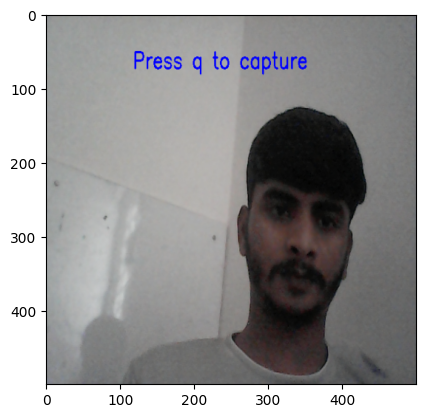

In [19]:
root=Tk()
b1=Button(root,text='clicl',command=example)
b1.place(x=50,y=50)
root.mainloop()

In [92]:
video_capture.release()
cv2.destroyAllWindows()

NameError: name 'video_capture' is not defined

In [145]:
conn=sqlite3.connect('Attendance.db')
cursor=conn.cursor()
cursor.execute('select oid,* from present_list2')
records=cursor.fetchall()#fetchone,fetchmany(10)
for record in records:
    print(record)
conn.commit()
conn.close()

(1, '1nc21cd023', 'narsi', '12:2:2', '1:2')
(2, '8', 'jadeja', '2024-05-08', '4:57:11')
(3, '18', 'Kohli', '2024-05-08', '4:57:23')
(4, '7', 'Dhoni', '2024-05-08', '4:57:45')
(5, '18', 'Kohli', '2024-05-08', '5:20:32')


In [ ]:
conn=sqlite3.connect('Attendance.db')
cursor=conn.cursor()
cursor.execute("select NAMES from present_list2 where USNS=?", (enquire_usn,))
result=cursor.fetchall()
print(result[0][0])
conn.commit()
conn.close()

In [33]:
conn=sqlite3.connect('Attendance.db')
cursor=conn.cursor()
cursor.execute("select * from present_list2 ")
result=cursor.fetchall()
print(result)
conn.commit()
conn.close()

[('1nc21cd023', 'narsi', '12:2:2', '1:2'), ('8', 'jadeja', '2024-05-08', '4:57:11'), ('18', 'Kohli', '2024-05-08', '4:57:23'), ('7', 'Dhoni', '2024-05-08', '4:57:45'), ('18', 'Kohli', '2024-05-08', '5:20:32')]


In [54]:
with open('names.txt','r')as file:
    myl=file.readlines()
    if len(myl)>0:
        xx=myl[0]
        xx=str(xx)
        zz=xx.split(',')
        zz=zz[:-1]
        print(zz)
    else:
        print(myl)

['Dhoni']
